In [28]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import f1_score

In [29]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
import random

seed = 42

torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)

In [30]:
#Basic Transforms
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (0.5, 0.5, 0.5),
        (0.5, 0.5, 0.5)
    )
    ])

#Download Dataset
train_dataset = datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

#Create DataLoaders
batch_size = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

In [31]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class HybridTwoStreamNetwork(nn.Module):
    def __init__(self):
        super(HybridTwoStreamNetwork, self).__init__()
        
        # ==========================================
        # BRANCH A: The CNN Feature Extractor (Local)
        # ==========================================
        # Input: 3x32x32 -> Conv1 -> Pool -> 32x16x16
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        
        # Input: 32x16x16 -> Conv2 -> Pool -> 64x8x8
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        
        # After two MaxPools (each cuts spatial size in half), the dimensions are 8x8.
        # Flattened size: 64 channels * 8 width * 8 height = 4096
        self.cnn_output_size = 64 * 8 * 8
        
        # ==========================================
        # BRANCH B: The MLP Pixel Memorizer (Global)
        # ==========================================
        # We use Average Pooling to downsample the massive 32x32 image to a small 8x8 image.
        # This gives a flattened input size of 3 channels * 8 * 8 = 192 features.
        self.mlp_input_size = 3 * 8 * 8
        
        self.mlp_fc1 = nn.Linear(self.mlp_input_size, 128)
        self.mlp_fc2 = nn.Linear(128, 64)
        
        # ==========================================
        # THE FUSION LAYER: Combining Both Branches
        # ==========================================
        # Total input to the final classifier is CNN output (4096) + MLP output (64) = 4160
        self.fusion_size = self.cnn_output_size + 64 
        
        # Final classification layer (10 classes for CIFAR-10)
        self.classifier = nn.Linear(self.fusion_size, 10)

    def forward(self, x):
        # -----------------------------
        # 1. Run Branch A (CNN)
        # -----------------------------
        cnn_out = self.conv1(x)
        cnn_out = self.bn1(cnn_out)
        cnn_out = F.relu(cnn_out)
        cnn_out = F.max_pool2d(cnn_out, 2)
        
        cnn_out = self.conv2(cnn_out)
        cnn_out = self.bn2(cnn_out)
        cnn_out = F.relu(cnn_out)
        cnn_out = F.max_pool2d(cnn_out, 2)
        
        # Flatten CNN spatial grid into a 1D vector
        cnn_out = cnn_out.view(cnn_out.size(0), -1) 
        
        # -----------------------------
        # 2. Run Branch B (MLP)
        # -----------------------------
        # Downsample the original image to 8x8 to prevent the parameter explosion
        mlp_out = F.avg_pool2d(x, 4) 
        
        # Flatten the downsampled image
        mlp_out = mlp_out.view(mlp_out.size(0), -1)
        
        # Pass through the linear MLP layers
        mlp_out = F.relu(self.mlp_fc1(mlp_out))
        mlp_out = F.relu(self.mlp_fc2(mlp_out))
        
        # -----------------------------
        # 3. Fusion & Classification
        # -----------------------------
        # Concatenate both vectors along the feature dimension (dim=1)
        combined_features = torch.cat((cnn_out, mlp_out), dim=1)
        
        # Final decision based on combined features
        final_output = self.classifier(combined_features)
        
        return final_output

In [32]:
# 6. Initialize Network
model = HybridTwoStreamNetwork().to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=0.001)

In [33]:
# 7. Training Function
def train(model, loader):

    model.train()

    running_loss = 0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    gradient_norms = {}

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        # Save gradient norms
        for name, param in model.named_parameters():

            if param.grad is not None:

                grad_norm = param.grad.norm().item()

                if name not in gradient_norms:
                    gradient_norms[name] = []

                gradient_norms[name].append(grad_norm)

        optimizer.step()

        running_loss += loss.item()

        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

        total += labels.size(0)

        correct += predicted.eq(labels).sum().item()

    accuracy = 100 * correct / total
    train_f1 = f1_score(all_labels, all_preds, average="macro")

    avg_loss = running_loss / len(loader)

    return avg_loss, accuracy, train_f1, gradient_norms

In [34]:
# 8. Testing Function
def test(model, loader):

    model.eval()

    running_loss = 0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item()

            _, predicted = outputs.max(1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            total += labels.size(0)

            correct += predicted.eq(labels).sum().item()

    accuracy = 100 * correct / total
    test_f1 = f1_score(all_labels, all_preds, average="macro")

    avg_loss = running_loss / len(loader)

    return avg_loss, accuracy, test_f1

In [35]:
num_epochs = 15

train_losses = []
test_losses = []

train_accs = []
test_accs = []
train_f1s = []
test_f1s = []
all_epoch_gradient_norms = []

for epoch in range(num_epochs):

    # 1. Run training and testing
    train_loss, train_acc, train_f1, grad_norms = train(model, train_loader)
    test_loss, test_acc, test_f1 = test(model, test_loader)

    # 2. Storage
    train_losses.append(train_loss)
    test_losses.append(test_loss)
    train_accs.append(train_acc)
    test_accs.append(test_acc)
    train_f1s.append(train_f1)
    test_f1s.append(test_f1)
    
    # 3. Process Gradients (Fixed variable name here)
    epoch_grad_averages = {}
    for layer_name, batch_norms in grad_norms.items():
        epoch_grad_averages[layer_name] = sum(batch_norms) / len(batch_norms)
    
    all_epoch_gradient_norms.append(epoch_grad_averages)
    
    # 4. MONITORING
    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"Train Loss: {train_loss:.4f} | Test Loss: {test_loss:.4f}")
    print(f"Train Accuracy: {train_acc:.2f}% | Test Accuracy: {test_acc:.2f}%")
    print(f"Train F1: {train_f1:.4f} | Test F1: {test_f1:.4f}")

    # --- ADDED: Print Gradient Magnitudes ---
    print("Average Gradient Magnitudes:")
    for layer, magnitude in epoch_grad_averages.items():
        # Using :.6f because these numbers might be very small!
        print(f"  {layer}: {magnitude:.6f}")

    print("-" * 40)

Epoch 1/15
Train Loss: 1.2843 | Test Loss: 1.0641
Train Accuracy: 54.93% | Test Accuracy: 62.47%
Train F1: 0.5480 | Test F1: 0.6216
Average Gradient Magnitudes:
  conv1.weight: 2.118637
  conv1.bias: 0.000015
  bn1.weight: 0.082599
  bn1.bias: 0.054192
  conv2.weight: 1.194610
  conv2.bias: 0.000000
  bn2.weight: 0.130533
  bn2.bias: 0.131328
  mlp_fc1.weight: 0.040787
  mlp_fc1.bias: 0.007214
  mlp_fc2.weight: 0.047688
  mlp_fc2.bias: 0.010628
  classifier.weight: 5.641701
  classifier.bias: 0.115830
----------------------------------------
Epoch 2/15
Train Loss: 0.9452 | Test Loss: 0.9621
Train Accuracy: 67.08% | Test Accuracy: 66.41%
Train F1: 0.6698 | Test F1: 0.6637
Average Gradient Magnitudes:
  conv1.weight: 3.373436
  conv1.bias: 0.000018
  bn1.weight: 0.113070
  bn1.bias: 0.070009
  conv2.weight: 1.213629
  conv2.bias: 0.000000
  bn2.weight: 0.169890
  bn2.bias: 0.169709
  mlp_fc1.weight: 0.070497
  mlp_fc1.bias: 0.013019
  mlp_fc2.weight: 0.084777
  mlp_fc2.bias: 0.015103
  c

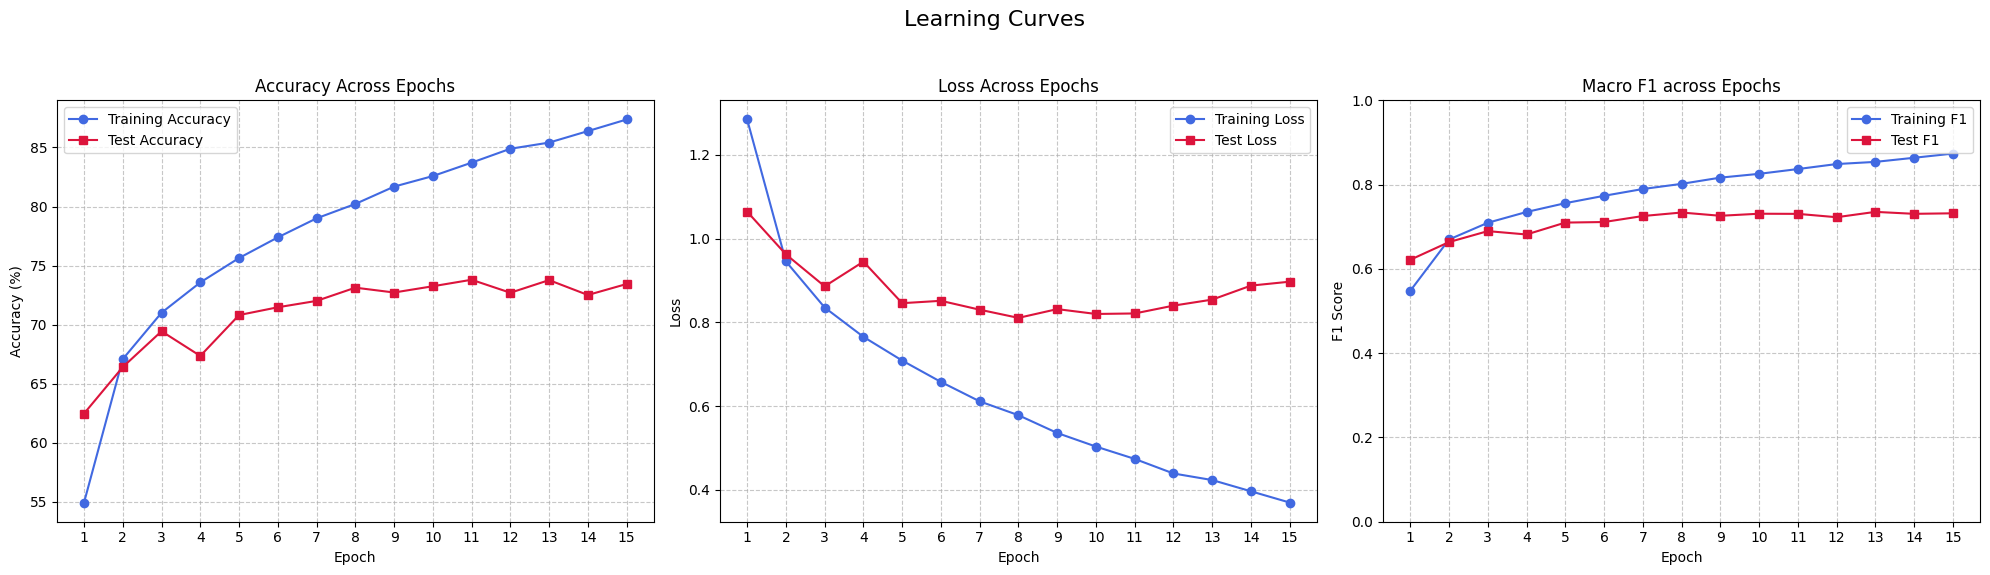

In [ ]:
import matplotlib.pyplot as plt

# Define the epoch range (1 to num_epochs)
epochs = range(1, num_epochs + 1)

# Create the main figure
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Learning Curves', fontsize=16)

# --- Plot 1: Accuracy ---
ax1.plot(epochs, train_accs, marker='o', label='Training Accuracy', color='royalblue')
ax1.plot(epochs, test_accs, marker='s', label='Test Accuracy', color='crimson')
ax1.set_title('Accuracy Across Epochs')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy (%)')
ax1.set_xticks(epochs) # Ensure axis shows every epoch from 1 to num_epochs
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.7)

# --- Plot 2: Loss ---
ax2.plot(epochs, train_losses, marker='o', label='Training Loss', color='royalblue')
ax2.plot(epochs, test_losses, marker='s', label='Test Loss', color='crimson')
ax2.set_title('Loss Across Epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.set_xticks(epochs) # Ensure axis shows every epoch from 1 to num_epochs
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.7)

# --- Plot 3: F1 Score ---
ax3.plot(epochs, train_f1s, marker='o', label='Training F1', color='royalblue')
ax3.plot(epochs, test_f1s, marker='s', label='Test F1', color='crimson')
ax3.set_title('Macro F1 across Epochs')
ax3.set_xlabel('Epoch')
ax3.set_ylabel('F1 Score')
ax3.set_xticks(epochs)
ax3.set_ylim(0, 1)
ax3.legend()
ax3.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to make room for suptitle
plt.show()

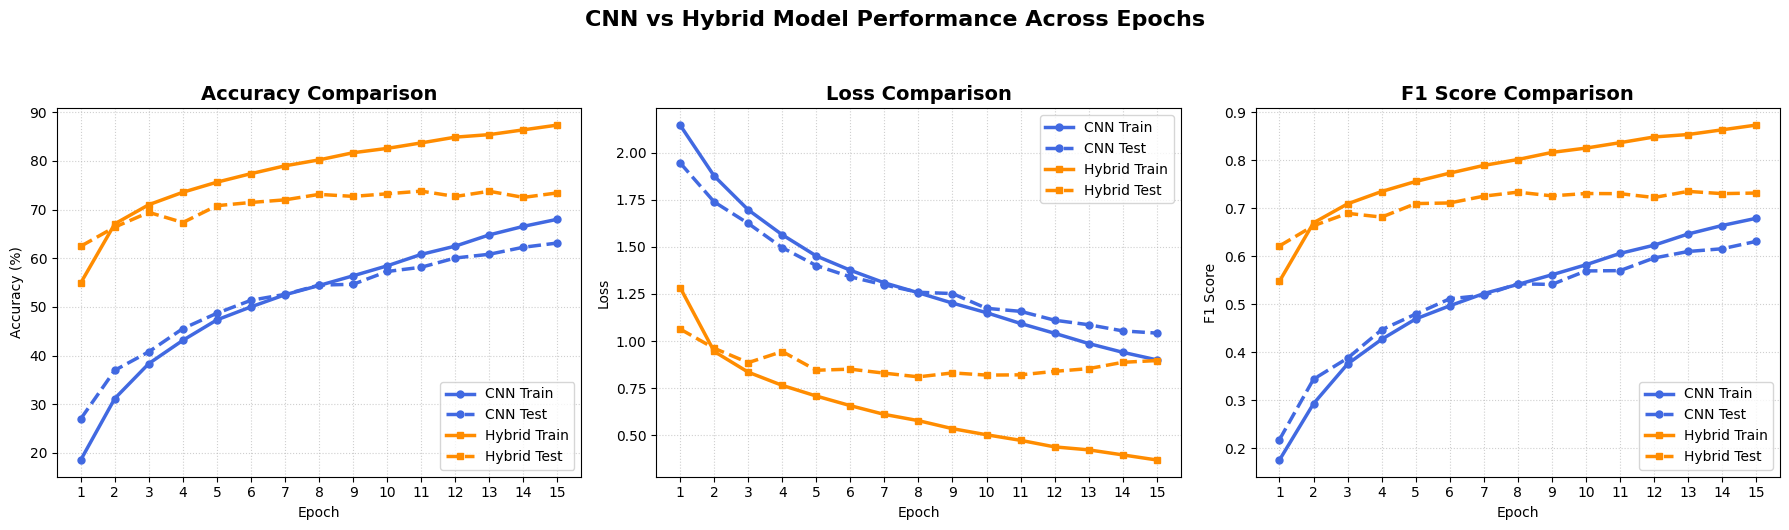

In [ ]:
import matplotlib.pyplot as plt

# Epochs
epochs = range(1, 16)

# ----------------------------------------------------
# Data from Dataset 1: CNN debugged
# ----------------------------------------------------
train_loss_cnn = [2.1461, 1.8759, 1.6964, 1.5641, 1.4518, 1.3760, 1.3092, 1.2564, 1.2017, 1.1507, 1.0936, 1.0415, 0.9872, 0.9407, 0.9006]
test_loss_cnn  = [1.9457, 1.7386, 1.6244, 1.4958, 1.4008, 1.3410, 1.2982, 1.2592, 1.2523, 1.1740, 1.1579, 1.1109, 1.0869, 1.0543, 1.0425]

train_acc_cnn = [18.56, 31.19, 38.37, 43.15, 47.35, 50.02, 52.51, 54.41, 56.40, 58.45, 60.80, 62.50, 64.81, 66.56, 68.02]
test_acc_cnn  = [27.00, 36.99, 40.79, 45.56, 48.71, 51.37, 52.59, 54.49, 54.66, 57.29, 58.16, 60.06, 60.83, 62.27, 63.14]

train_f1_cnn = [0.1753, 0.2927, 0.3755, 0.4268, 0.4694, 0.4968, 0.5223, 0.5413, 0.5614, 0.5823, 0.6060, 0.6231, 0.6465, 0.6642, 0.6792]
test_f1_cnn  = [0.2178, 0.3438, 0.3876, 0.4468, 0.4795, 0.5114, 0.5187, 0.5427, 0.5413, 0.5695, 0.5701, 0.5964, 0.6100, 0.6157, 0.6311]


# ----------------------------------------------------
# Data from Dataset 2: Hybrid Model
# ----------------------------------------------------
train_loss_hybrid = [1.2843, 0.9452, 0.8353, 0.7652, 0.7086, 0.6576, 0.6112, 0.5781, 0.5356, 0.5032, 0.4737, 0.4389, 0.4232, 0.3964, 0.3695]
test_loss_hybrid  = [1.0641, 0.9621, 0.8859, 0.9448, 0.8456, 0.8513, 0.8300, 0.8105, 0.8314, 0.8198, 0.8211, 0.8397, 0.8541, 0.8876, 0.8969]

train_acc_hybrid = [54.93, 67.08, 71.01, 73.57, 75.64, 77.39, 79.00, 80.22, 81.69, 82.58, 83.71, 84.89, 85.41, 86.39, 87.37]
test_acc_hybrid  = [62.47, 66.41, 69.44, 67.35, 70.81, 71.47, 72.01, 73.13, 72.72, 73.25, 73.80, 72.70, 73.77, 72.51, 73.44]

train_f1_hybrid = [0.5480, 0.6698, 0.7094, 0.7351, 0.7560, 0.7734, 0.7895, 0.8018, 0.8166, 0.8256, 0.8369, 0.8488, 0.8539, 0.8637, 0.8736]
test_f1_hybrid  = [0.6216, 0.6637, 0.6896, 0.6817, 0.7099, 0.7112, 0.7254, 0.7338, 0.7260, 0.7309, 0.7306, 0.7226, 0.7353, 0.7307, 0.7319]


# ----------------------------------------------------
# General visual settings
# ----------------------------------------------------
plt.figure(figsize=(18, 5))

cnn_color = "green"
hybrid_color = "darkorange"

train_style = "--"
test_style = "-"

line_width = 2.5
marker_size = 5


# ----------------------------------------------------
# Plot 1: Accuracy Comparison
# ----------------------------------------------------
plt.subplot(1, 3, 1)

plt.plot(epochs, train_acc_cnn, label="CNN Train", color=cnn_color,
         linestyle=train_style, linewidth=line_width, markersize=marker_size)

plt.plot(epochs, test_acc_cnn, label="CNN Test", color=cnn_color,
         linestyle=test_style, linewidth=line_width, markersize=marker_size)

plt.plot(epochs, train_acc_hybrid, label="Hybrid Train", color=hybrid_color,
         linestyle=train_style, linewidth=line_width, markersize=marker_size)

plt.plot(epochs, test_acc_hybrid, label="Hybrid Test", color=hybrid_color,
         linestyle=test_style, linewidth=line_width, markersize=marker_size)

plt.title("Accuracy Comparison", fontsize=16, fontweight="bold")
plt.xlabel("Epoch", fontsize=14, fontweight="bold")
plt.ylabel("Accuracy (%)", fontsize=14, fontweight="bold")
plt.xticks(epochs)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend()


# ----------------------------------------------------
# Plot 2: Loss Comparison
# ----------------------------------------------------
plt.subplot(1, 3, 2)

plt.plot(epochs, train_loss_cnn, label="CNN Train", color=cnn_color,
         linestyle=train_style, linewidth=line_width, markersize=marker_size)

plt.plot(epochs, test_loss_cnn, label="CNN Test", color=cnn_color,
         linestyle=test_style, linewidth=line_width, markersize=marker_size)

plt.plot(epochs, train_loss_hybrid, label="Hybrid Train", color=hybrid_color,
         linestyle=train_style, linewidth=line_width, markersize=marker_size)

plt.plot(epochs, test_loss_hybrid, label="Hybrid Test", color=hybrid_color,
         linestyle=test_style, linewidth=line_width, markersize=marker_size)

plt.title("Loss Comparison", fontsize=16, fontweight="bold")
plt.xlabel("Epoch", fontsize=14, fontweight="bold")
plt.ylabel("Loss", fontsize=14, fontweight="bold")
plt.xticks(epochs)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend()


# ----------------------------------------------------
# Plot 3: F1 Score Comparison
# ----------------------------------------------------
plt.subplot(1, 3, 3)

plt.plot(epochs, train_f1_cnn, label="CNN Train", color=cnn_color,
         linestyle=train_style, linewidth=line_width, markersize=marker_size)

plt.plot(epochs, test_f1_cnn, label="CNN Test", color=cnn_color,
         linestyle=test_style, linewidth=line_width, markersize=marker_size)

plt.plot(epochs, train_f1_hybrid, label="Hybrid Train", color=hybrid_color,
         linestyle=train_style, linewidth=line_width, markersize=marker_size)

plt.plot(epochs, test_f1_hybrid, label="Hybrid Test", color=hybrid_color,
         linestyle=test_style, linewidth=line_width, markersize=marker_size)

plt.title("F1 Score Comparison", fontsize=16, fontweight="bold")
plt.xlabel("Epoch", fontsize=14, fontweight="bold")
plt.ylabel("F1 Score", fontsize=14, fontweight="bold")
plt.xticks(epochs)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend()


# ----------------------------------------------------
# Final formatting
# ----------------------------------------------------
plt.suptitle("CNN vs Hybrid Model Performance Across Epochs", fontsize=16, fontweight="bold", y=1.05)
plt.tight_layout()
plt.show()